# CODING LLM ARCHITECTURE

In [1]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits



class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # A simple placeholder

    def forward(self, x):
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self, x):
        # This layer does nothing and just returns its input.
        return x

In [2]:
import tiktoken
tokenizer=tiktoken.get_encoding("gpt2")

batch=[]

txt1="every effort moves you"
txt2="every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))

batch=torch.stack(batch,dim=0)
print(batch)

tensor([[16833,  3626,  6100,   345],
        [16833,  1110,  6622,   257]])


In [3]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,      # Vocabulary size
    "context_length": 1024,   # Context length
    "emb_dim": 768,           # Embedding dimension
    "n_heads": 12,            # Number of attention heads
    "n_layers": 12,           # Number of layers
    "drop_rate": 0.1,         # Dropout rate
    "qkv_bias": False         # Query-Key-Value bias
}

In [4]:
torch.manual_seed(123)
model=DummyGPTModel(cfg=GPT_CONFIG_124M)

logits=model(batch)
print("output shape:-",logits.shape)
print(logits)

output shape:- torch.Size([2, 4, 50257])
tensor([[[-1.0327,  0.6600, -0.4785,  ..., -1.5241, -0.3608,  0.7456],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0406,  0.1050, -0.6027,  ..., -1.4415,  0.1323,  0.5012],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


## Layer Normalization [goal:- mean=0 variance=1]

In [5]:
torch.manual_seed(123)
batch_ex=torch.randn(2,5)
batch_ex

tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])

In [6]:
layer=nn.Sequential(nn.Linear(5,6),nn.ReLU())
op=layer(batch_ex)
op

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)

In [7]:
mean=op.mean(dim=-1,keepdim=True)
mean

tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)

In [8]:
var=op.var(dim=-1,keepdim=True)
var

tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)

In [9]:
torch.set_printoptions(sci_mode=False)

In [10]:
norm=((op-mean)/torch.sqrt(var))
norm.var(dim=1,keepdim=True)

tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)

In [11]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [12]:
ln=LayerNorm(6)
norm_op=ln(op)

In [13]:
norm_op

tensor([[ 0.6745,  1.5470, -0.9549,  0.6431, -0.9549, -0.9549],
        [-0.0207,  0.1228, -1.1913,  1.6619,  0.6186, -1.1913]],
       grad_fn=<AddBackward0>)

In [14]:
norm_op.mean(dim=-1,keepdim=True)

tensor([[ 0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)

In [15]:
norm_op.var(dim=-1,keepdim=True,unbiased=False)

tensor([[0.9995],
        [0.9997]], grad_fn=<VarBackward0>)

## Implementing a Feed Forward Network [GELU]

In [16]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()


    def forward(self,x):
        return 0.5*x*(1+torch.tanh(
            torch.sqrt(torch.tensor(2.0/torch.pi))*
            (x+0.044715*torch.pow(x,3))
        ))

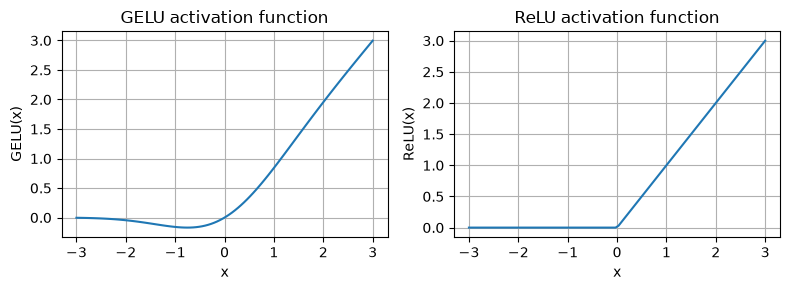

In [17]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

# Some sample data
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))

for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]), #768 -> 3072
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]), #3072 -> 768
        )

    def forward(self, x):
        return self.layers(x)

In [19]:
ffn= FeedForward(GPT_CONFIG_124M)

In [20]:
x=torch.rand(2,3,768)
ffn(x).shape

torch.Size([2, 3, 768])

In [21]:
ffn.layers

Sequential(
  (0): Linear(in_features=768, out_features=3072, bias=True)
  (1): GELU()
  (2): Linear(in_features=3072, out_features=768, bias=True)
)

In [22]:
ffn.layers[0].weight

Parameter containing:
tensor([[-0.0223,  0.0308,  0.0022,  ..., -0.0174, -0.0227, -0.0178],
        [-0.0027, -0.0043, -0.0274,  ...,  0.0079,  0.0112,  0.0010],
        [-0.0029,  0.0175,  0.0244,  ..., -0.0164, -0.0300,  0.0045],
        ...,
        [ 0.0255,  0.0023,  0.0277,  ..., -0.0037, -0.0134, -0.0284],
        [ 0.0266,  0.0236, -0.0193,  ...,  0.0120,  0.0061, -0.0261],
        [ 0.0222,  0.0106, -0.0190,  ..., -0.0253,  0.0320, -0.0109]],
       requires_grad=True)

## adding shortcut connection 
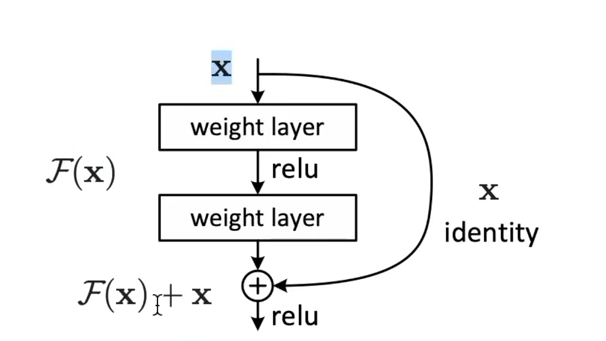

In [23]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)

            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output

        return x

def print_gradients(model,x):
    output=model(x)
    target=torch.tensor([[0.]])

    loss=nn.MSELoss()
    loss=loss(output,target)
    loss.backward()


    for name,param in model.named_parameters():
        if "weight" in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")   

In [24]:
layer_sizes=[3,3,3,3,3,1]
sample_input=torch.tensor([[1.,0.,1.]])

In [25]:
torch.manual_seed(123)
model_without_shortcut=ExampleDeepNeuralNetwork(
    layer_sizes,use_shortcut=False
)
print_gradients(model_without_shortcut,sample_input)

layers.0.0.weight has gradient mean of 0.00015044710016809404
layers.1.0.weight has gradient mean of 0.00013967031554784626
layers.2.0.weight has gradient mean of 0.0006069596274755895
layers.3.0.weight has gradient mean of 0.0011254228884354234
layers.4.0.weight has gradient mean of 0.004502863623201847


In [26]:
torch.manual_seed(123)
model_with_shortcut=ExampleDeepNeuralNetwork(
    layer_sizes,use_shortcut=True
)
print_gradients(model_with_shortcut,sample_input)

layers.0.0.weight has gradient mean of 0.231016606092453
layers.1.0.weight has gradient mean of 0.2370775043964386
layers.2.0.weight has gradient mean of 0.34811025857925415
layers.3.0.weight has gradient mean of 0.13332872092723846
layers.4.0.weight has gradient mean of 1.8219518661499023


## TRANSFORMER BLOCK

In [27]:
import torch
import torch.nn as nn
from Multiheadattention import MultiHeadAttention

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )

        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape: [batch_size, num_tokens, emb_dim]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed-forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

In [28]:
torch.manual_seed(123)
x=torch.rand(2,4,768)
block=TransformerBlock(GPT_CONFIG_124M)
output=block(x)
x.shape #Input shape

torch.Size([2, 4, 768])

In [30]:
output.shape #output shape

torch.Size([2, 4, 768])

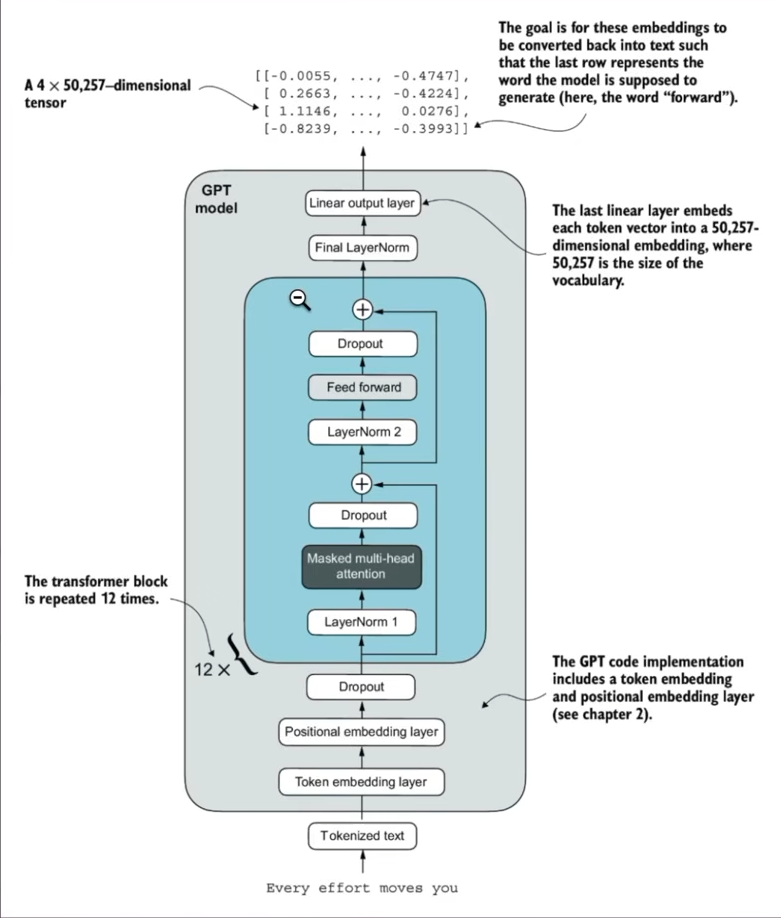

## Coding GPT model

In [31]:
import torch
import torch.nn as nn

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape

        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )

        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)

        return logits

In [32]:
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)

In [33]:
import tiktoken
tokenizer=tiktoken.get_encoding("gpt2")

batch=[]

txt1="every effort moves you"
txt2="every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))

batch=torch.stack(batch,dim=0)
print(batch)

tensor([[16833,  3626,  6100,   345],
        [16833,  1110,  6622,   257]])


In [34]:
out=model(batch)

In [36]:
batch.shape

torch.Size([2, 4])

In [37]:
out.shape

torch.Size([2, 4, 50257])

In [44]:
print(f"number of elements 2 * 4 :- {batch.numel()}")

total_parameters=sum(p.numel() for p in model.parameters())
print(f"total parameters:-{total_parameters:,}")

number of elements 2 * 4 :- 8
total parameters:-163,009,536


In [46]:
print("weight matrix:-",model.tok_emb.weight.shape)
print("output matrix:-",model.out_head.weight.shape)

weight matrix:- torch.Size([50257, 768])
output matrix:- torch.Size([50257, 768])


In [48]:
print(f"total parameters:-{total_parameters-model.out_head.weight.numel():,}") 
#gives the number of parameters without counting the output projection layer.

total parameters:-124,412,160
